In [1]:
import pandas as pd

# Read CSV
df = pd.read_csv("../data/customer_churn_test.csv")

# Drop the customer ID column as it has no useful information
df = df.drop(columns=["CustomerID"])

# Display head
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [2]:
# Check the datatypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                64374 non-null  int64
 1   Gender             64374 non-null  str  
 2   Tenure             64374 non-null  int64
 3   Usage Frequency    64374 non-null  int64
 4   Support Calls      64374 non-null  int64
 5   Payment Delay      64374 non-null  int64
 6   Subscription Type  64374 non-null  str  
 7   Contract Length    64374 non-null  str  
 8   Total Spend        64374 non-null  int64
 9   Last Interaction   64374 non-null  int64
 10  Churn              64374 non-null  int64
dtypes: int64(8), str(3)
memory usage: 5.4 MB


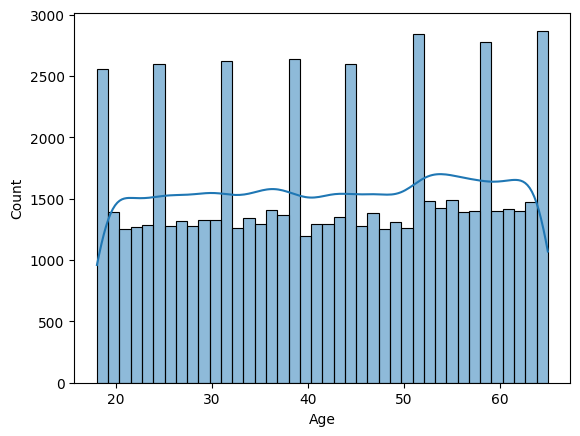

In [3]:
# Display the distribution of age
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Age"], kde=True)
plt.show()

/var/folders/gr/b7qhgnxs1tsdyx_r9qphz9740000gn/T/ipykernel_6297/3434856849.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=df, x="Age Group", y="Churn", palette="viridis", ci=None)
/var/folders/gr/b7qhgnxs1tsdyx_r9qphz9740000gn/T/ipykernel_6297/3434856849.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x="Age Group", y="Churn", palette="viridis", ci=None)


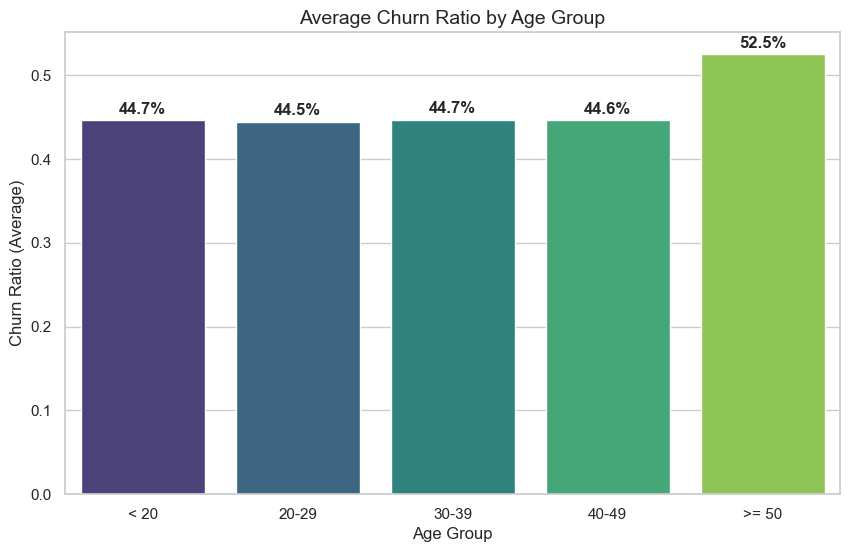

In [4]:
# 1. Define the bins and labels based on your requirements
bins = [0, 20, 30, 40, 50, 120]  # 120 acts as an upper bound for >= 50
labels = ["< 20", "20-29", "30-39", "40-49", ">= 50"]

# 2. Segment the data
# 'right=False' ensures the ranges are [low, high), e.g., 20 is included in '20-29'
df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels, right=False)

# 3. Plot the average churn ratio
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# sns.barplot defaults to calculating the mean (ratio) if Churn is 0 or 1
ax = sns.barplot(data=df, x="Age Group", y="Churn", palette="viridis", ci=None)

# Formatting the chart
plt.title("Average Churn Ratio by Age Group", fontsize=14)
plt.ylabel("Churn Ratio (Average)", fontsize=12)
plt.xlabel("Age Group", fontsize=12)

# Optional: Add percentage labels on top of bars
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
        fontweight="bold",
    )
plt.show()

Strong connection between Churn ratio and age group. Teenagers and elderly are most likely to churn. Beside those groups, churn ratio seems to decrease with age.

<Axes: xlabel='Gender', ylabel='Count'>

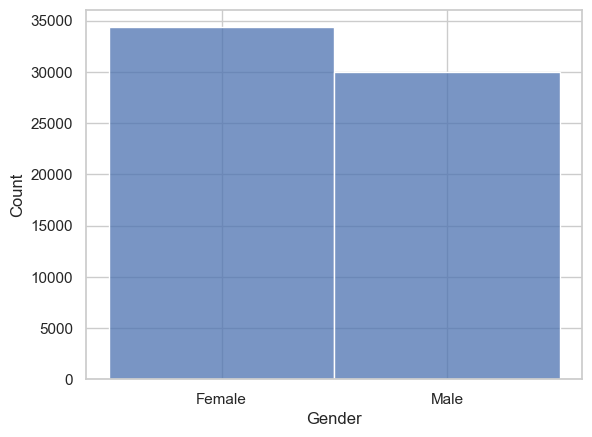

In [5]:
# Plot the male / female ratio
sns.histplot(df["Gender"])

/var/folders/gr/b7qhgnxs1tsdyx_r9qphz9740000gn/T/ipykernel_6297/554327809.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=df, x="Gender", y="Churn", palette="magma", ci=None)
/var/folders/gr/b7qhgnxs1tsdyx_r9qphz9740000gn/T/ipykernel_6297/554327809.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x="Gender", y="Churn", palette="magma", ci=None)


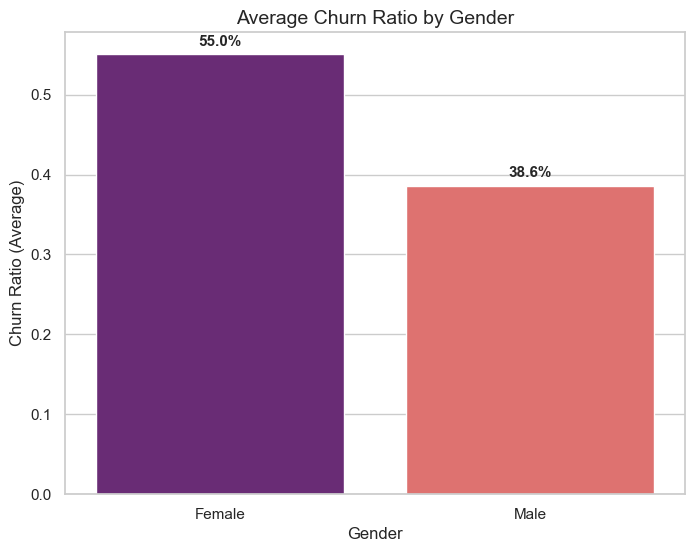

In [6]:
# 1. Plotting the average churn ratio by Gender
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# Seaborn's barplot automatically calculates the mean of 'Churn' (the ratio)
# for each category in 'Gender'
ax = sns.barplot(data=df, x="Gender", y="Churn", palette="magma", ci=None)

# 2. Formatting and labels
plt.title("Average Churn Ratio by Gender", fontsize=14)
plt.ylabel("Churn Ratio (Average)", fontsize=12)
plt.xlabel("Gender", fontsize=12)

# 3. Add percentage labels on top of the bars for clarity
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 9),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
    )

plt.show()

We can see that females are more likely to churn than male

<Axes: xlabel='Tenure', ylabel='Count'>

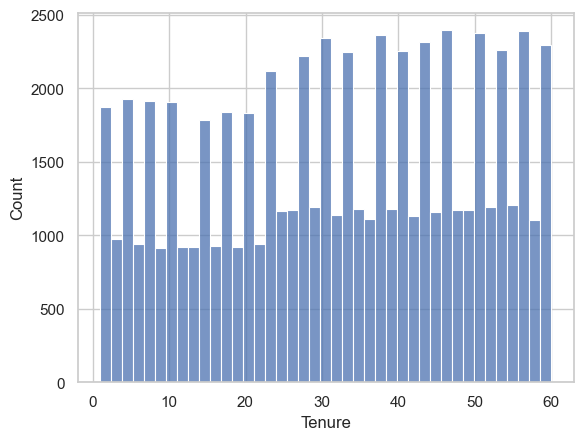

In [7]:
# Plot the distribution of tenure
# Pretty standard uniform distribution
sns.histplot(df["Tenure"])

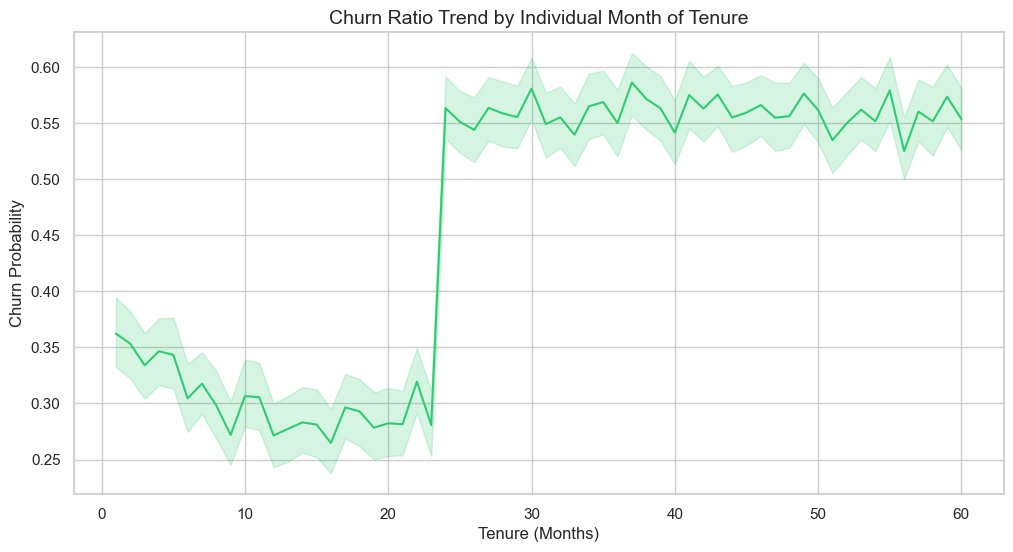

In [8]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Line plot shows the mean churn ratio for every unit of tenure
sns.lineplot(data=df, x="Tenure", y="Churn", color="#2ecc71")

plt.title("Churn Ratio Trend by Individual Month of Tenure", fontsize=14)
plt.ylabel("Churn Probability")
plt.xlabel("Tenure (Months)")
plt.show()

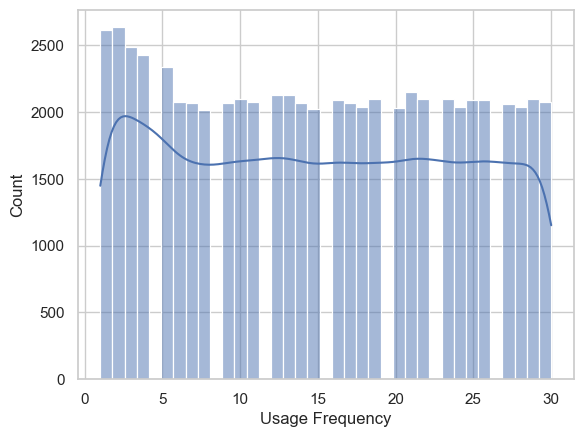

In [9]:
# Plot the distribution of usage frequency
# Again pretty uniform distribution
sns.histplot(df["Usage Frequency"], kde=True)
plt.show()

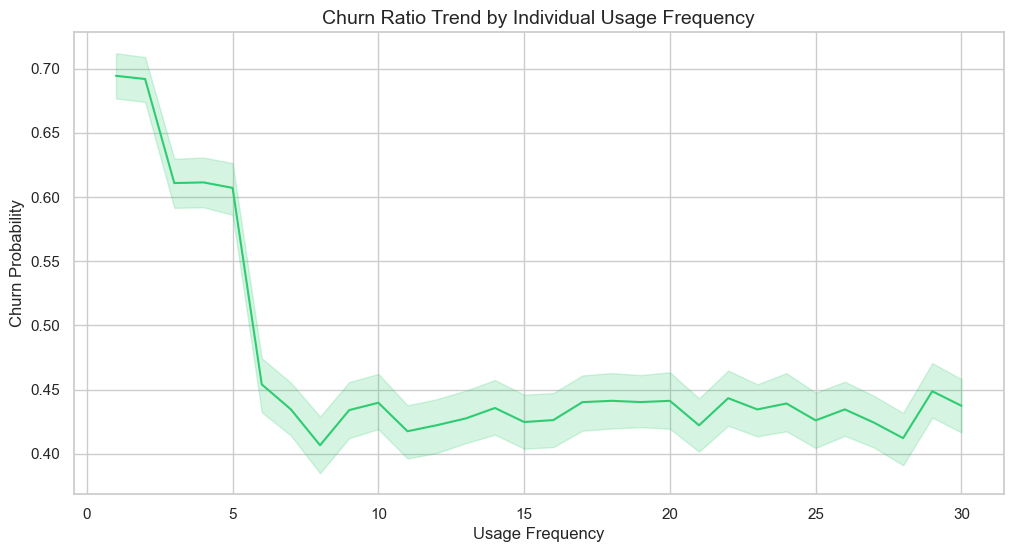

In [10]:
# Plot usage frequency against churn
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Line plot shows the mean churn ratio for every unit of tenure
sns.lineplot(data=df, x="Usage Frequency", y="Churn", color="#2ecc71")

plt.title("Churn Ratio Trend by Individual Usage Frequency", fontsize=14)
plt.ylabel("Churn Probability")
plt.xlabel("Usage Frequency")
plt.show()

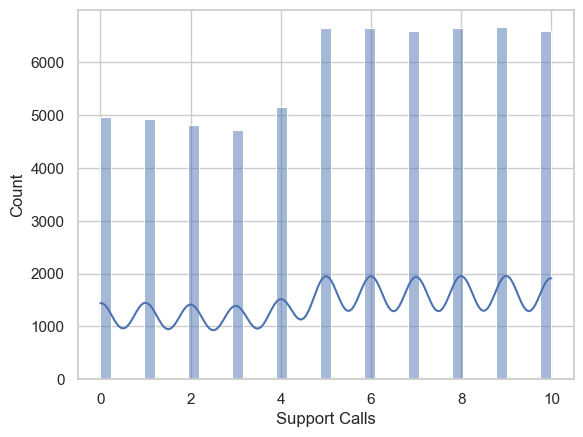

In [11]:
# Plot the distribution of support call
sns.histplot(df["Support Calls"], kde=True)
plt.show()

/var/folders/gr/b7qhgnxs1tsdyx_r9qphz9740000gn/T/ipykernel_6297/1909892353.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=df, x="Support Calls", y="Churn", palette="Reds", ci=None)
/var/folders/gr/b7qhgnxs1tsdyx_r9qphz9740000gn/T/ipykernel_6297/1909892353.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x="Support Calls", y="Churn", palette="Reds", ci=None)


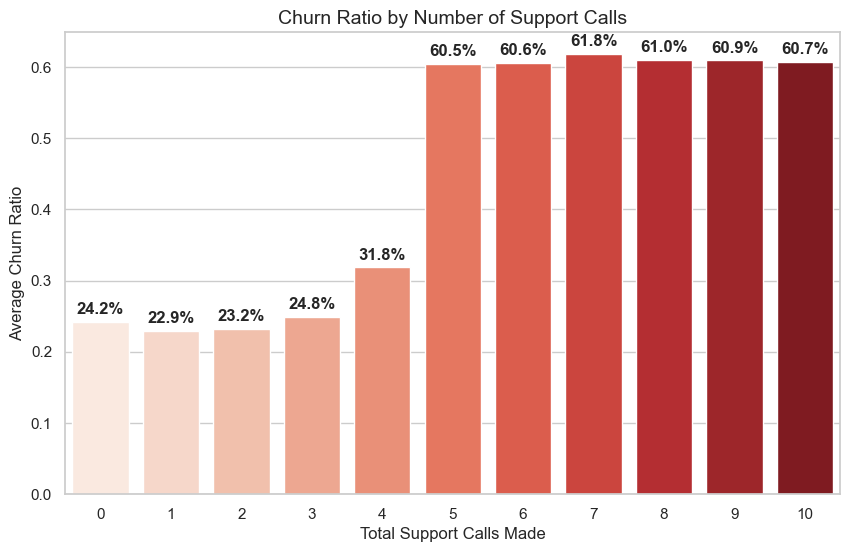

In [12]:
# 1. Visualization Setup
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 2. Create the bar plot
# 'Support Calls' is the x-axis, and the mean of 'Churn' is the ratio
ax = sns.barplot(data=df, x="Support Calls", y="Churn", palette="Reds", ci=None)

# 3. Formatting
plt.title("Churn Ratio by Number of Support Calls", fontsize=14)
plt.ylabel("Average Churn Ratio", fontsize=12)
plt.xlabel("Total Support Calls Made", fontsize=12)

# 4. Add data labels to see the exact percentage for each "call group"
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 9),
        textcoords="offset points",
        fontweight="bold",
    )

plt.show()

If support call is hight, 100% more likely to churn

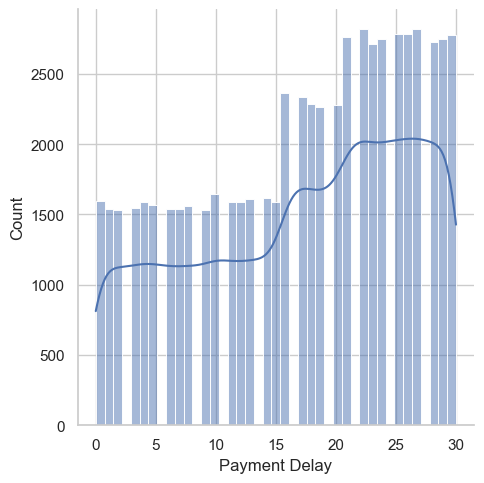

In [13]:
# Plot payment delay distribution
sns.displot(df["Payment Delay"], kde=True)
plt.show()

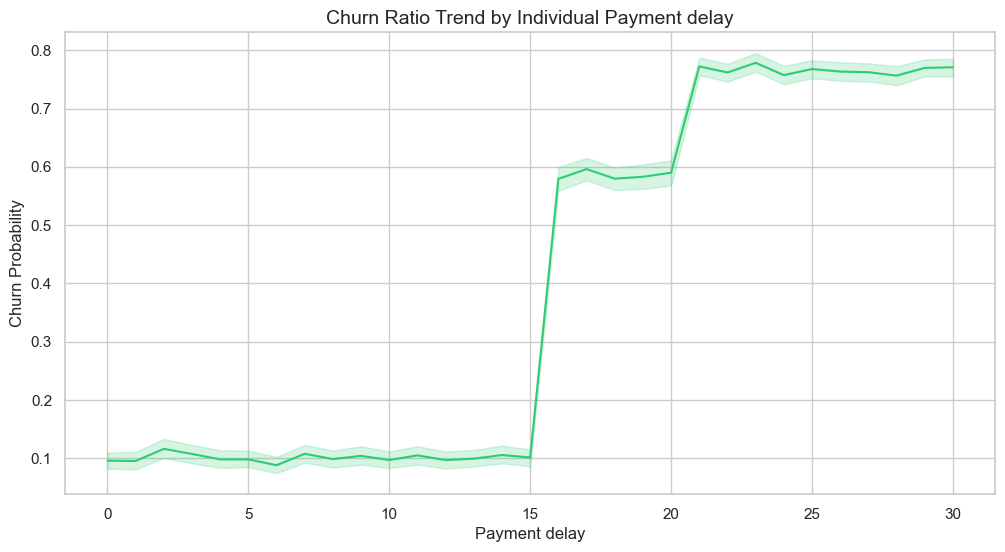

In [14]:
# Plot payment delay vs churn ratio
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Line plot shows the mean churn ratio for every unit of tenure
sns.lineplot(data=df, x="Payment Delay", y="Churn", color="#2ecc71")

plt.title("Churn Ratio Trend by Individual Payment delay", fontsize=14)
plt.ylabel("Churn Probability")
plt.xlabel("Payment delay")
plt.show()

More than 20 payment delay => 100% churn ratio

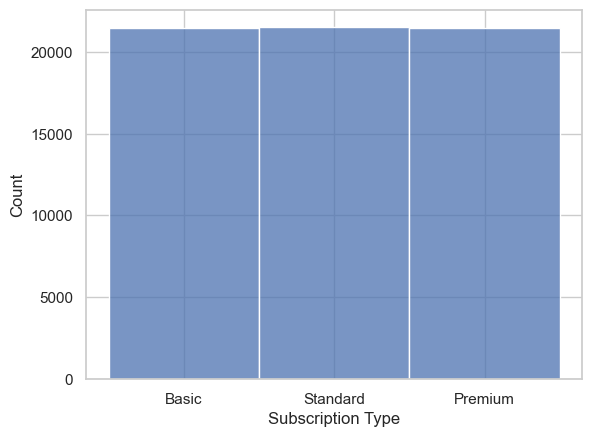

In [15]:
# Standard uniform distribution
sns.histplot(df["Subscription Type"])
plt.show()

/var/folders/gr/b7qhgnxs1tsdyx_r9qphz9740000gn/T/ipykernel_6297/3076823657.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=df, x="Subscription Type", y="Churn", palette="magma", ci=None)
/var/folders/gr/b7qhgnxs1tsdyx_r9qphz9740000gn/T/ipykernel_6297/3076823657.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x="Subscription Type", y="Churn", palette="magma", ci=None)


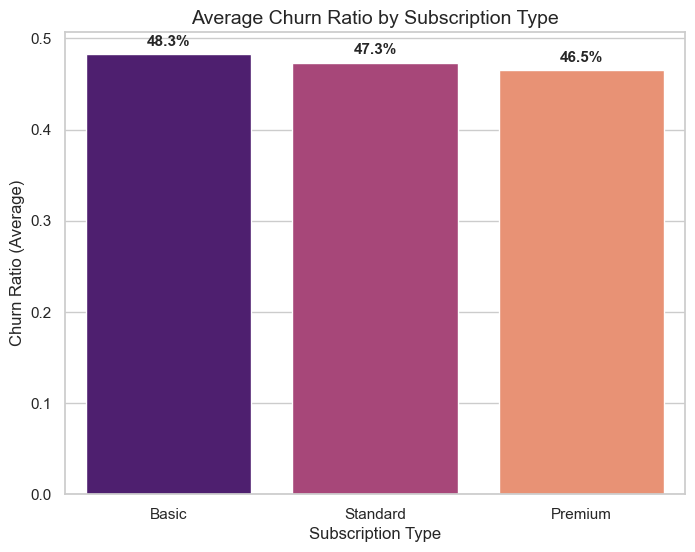

In [16]:
# 1. Plotting the average churn ratio by Gender
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# Seaborn's barplot automatically calculates the mean of 'Churn' (the ratio)
# for each category in 'Gender'
ax = sns.barplot(data=df, x="Subscription Type", y="Churn", palette="magma", ci=None)

# 2. Formatting and labels
plt.title("Average Churn Ratio by Subscription Type", fontsize=14)
plt.ylabel("Churn Ratio (Average)", fontsize=12)
plt.xlabel("Subscription Type", fontsize=12)

# 3. Add percentage labels on top of the bars for clarity
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 9),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
    )

plt.show()

Subscription types does not matter much for churn ratio.

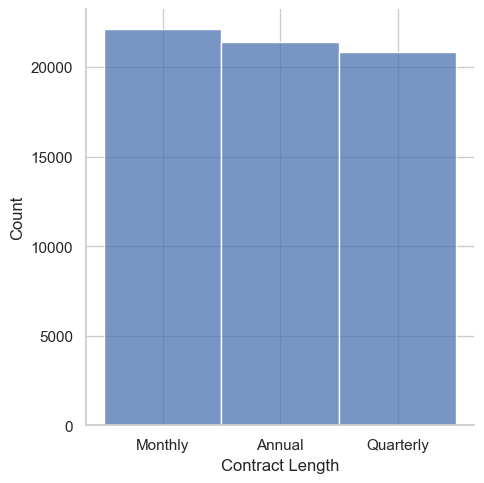

In [17]:
# For contract length
# Mostly annually and quaterly
sns.displot(df["Contract Length"])
plt.show()

/var/folders/gr/b7qhgnxs1tsdyx_r9qphz9740000gn/T/ipykernel_6297/480884385.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=df, x="Contract Length", y="Churn", palette="magma", ci=None)
/var/folders/gr/b7qhgnxs1tsdyx_r9qphz9740000gn/T/ipykernel_6297/480884385.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x="Contract Length", y="Churn", palette="magma", ci=None)


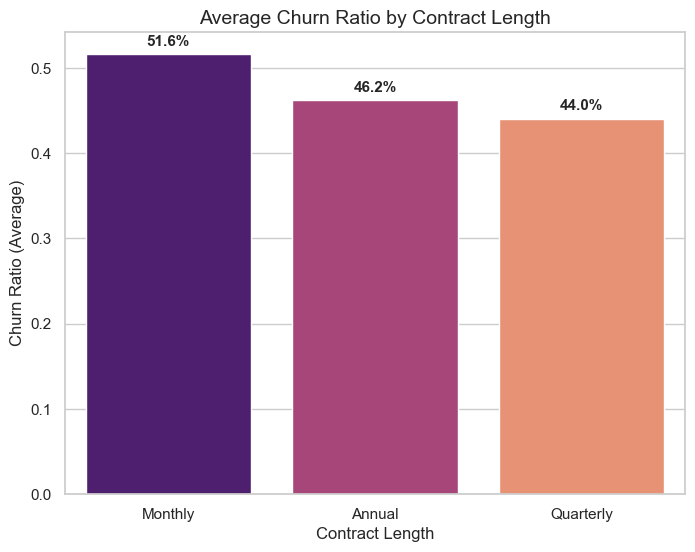

In [18]:
# 1. Plotting the average churn ratio by Gender
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# Seaborn's barplot automatically calculates the mean of 'Churn' (the ratio)
# for each category in 'Gender'
ax = sns.barplot(data=df, x="Contract Length", y="Churn", palette="magma", ci=None)

# 2. Formatting and labels
plt.title("Average Churn Ratio by Contract Length", fontsize=14)
plt.ylabel("Churn Ratio (Average)", fontsize=12)
plt.xlabel("Contract Length", fontsize=12)

# 3. Add percentage labels on top of the bars for clarity
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 9),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
    )

plt.show()

Monthly is 100% likely to churn, annually and quaterly has similay churning ratios.

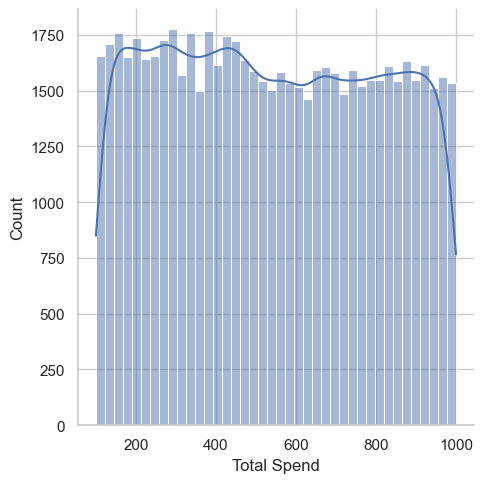

In [19]:
# Plot total spending
# Two distinct groups
sns.displot(df["Total Spend"], kde=True)
plt.show()

/var/folders/gr/b7qhgnxs1tsdyx_r9qphz9740000gn/T/ipykernel_6297/759298514.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x="Spend Group", y="Churn", palette="coolwarm", errorbar=None)


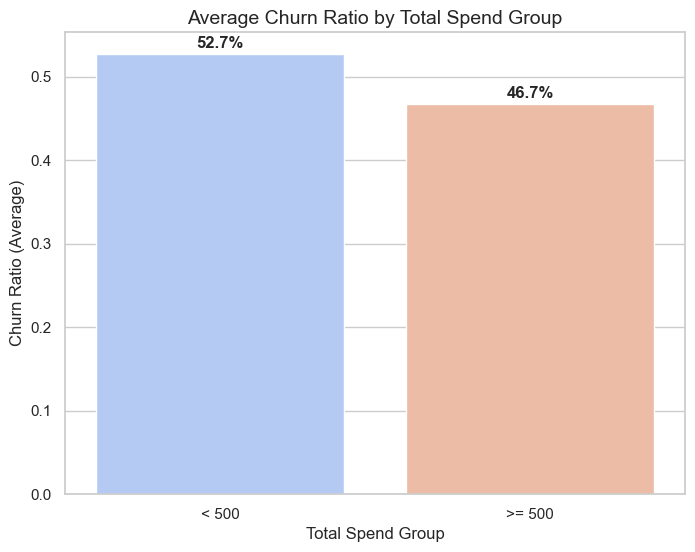

In [20]:
import numpy as np

# 1. Define the bins and labels for Total Spend
# np.inf catches all values >= 500
bins = [0, 200, np.inf]
labels = ["< 500", ">= 500"]

# 2. Segment the data
# 'right=False' ensures the groups are [0, 500) and [500, infinity)
df["Spend Group"] = pd.cut(df["Total Spend"], bins=bins, labels=labels, right=False)

# 3. Plot the average churn ratio
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# Using 'errorbar=None' as 'ci' is deprecated in newer Seaborn versions
ax = sns.barplot(data=df, x="Spend Group", y="Churn", palette="coolwarm", errorbar=None)

# Formatting the chart
plt.title("Average Churn Ratio by Total Spend Group", fontsize=14)
plt.ylabel("Churn Ratio (Average)", fontsize=12)
plt.xlabel("Total Spend Group", fontsize=12)

# Add percentage labels on top of bars
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
        fontweight="bold",
    )
plt.show()

Those with spending < 500 are extremly liely to churn

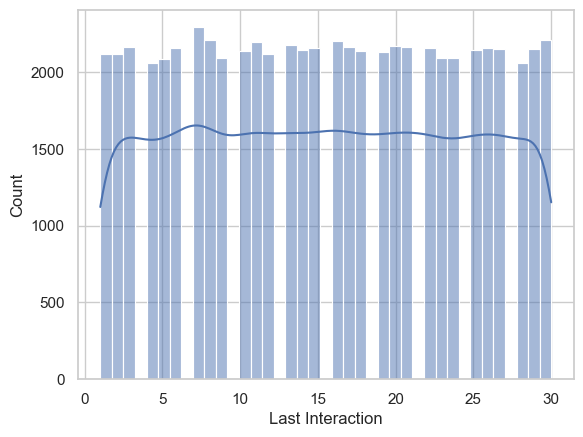

In [21]:
sns.histplot(df["Last Interaction"], kde=True)
plt.show()

/var/folders/gr/b7qhgnxs1tsdyx_r9qphz9740000gn/T/ipykernel_6297/525888719.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


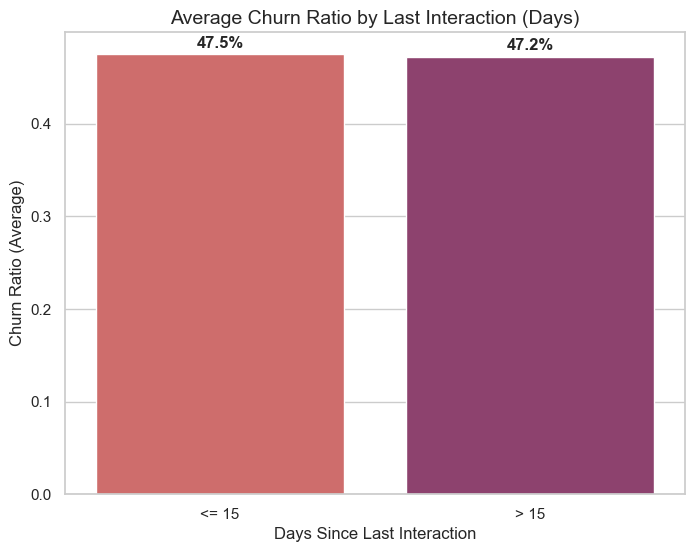

In [22]:
# 1. Define the bins and labels
# Using 15.1 and right=True ensures 15 is included in the first group
bins = [0, 15, np.inf]
labels = ["<= 15", "> 15"]

# 2. Segment the data
# 'right=True' makes the bins (left, right], so 15 falls into the first group
df["Interaction Group"] = pd.cut(
    df["Last Interaction"], bins=bins, labels=labels, include_lowest=True, right=True
)

# 3. Plot the average churn ratio
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df, x="Interaction Group", y="Churn", palette="flare", errorbar=None
)

# Formatting
plt.title("Average Churn Ratio by Last Interaction (Days)", fontsize=14)
plt.ylabel("Churn Ratio (Average)", fontsize=12)
plt.xlabel("Days Since Last Interaction", fontsize=12)

# Add percentage labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
        fontweight="bold",
    )
plt.show()

Last interaction high => More likely to churn

/var/folders/gr/b7qhgnxs1tsdyx_r9qphz9740000gn/T/ipykernel_6297/2700328807.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Churn"], kde=False)


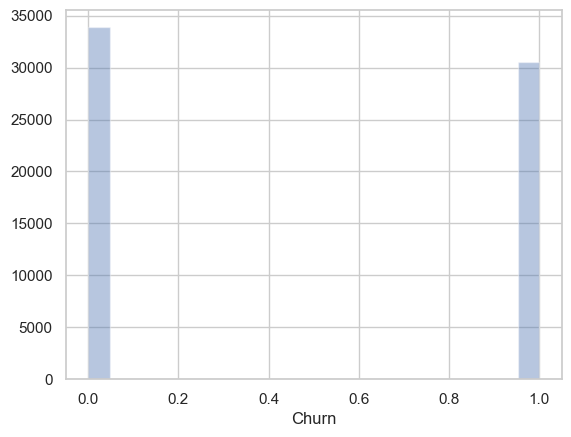

In [23]:
# Plot the churn distribution
# Pretty balance distribution
sns.distplot(df["Churn"], kde=False)
plt.show()

## Data analysis notes

Heavy data drift vs the original distribution